In [2]:
# ============================================================
# KLASIFIKASI PERFORMA AKADEMIK MAHASISWA BERDASARKAN
# KEBIASAAN HARIAN MENGGUNAKAN ALGORITMA DECISION TREE
# DAN NAIVE BAYES
# ============================================================
# Dataset : student_habits_performance.csv
# Jumlah Data : 1000 baris, 16 kolom
# ============================================================

# ============================================================
# 1. IMPORT LIBRARY
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

plt.style.use("ggplot")

## 3. Load Dataset
df = pd.read_csv('student_habits_performance.csv',sep=';',decimal=',')
df.head()




,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [3]:
# Exploratory Data Analysis (EDA)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [4]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [5]:
df.isnull().sum()

student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

In [6]:
# Mengisi missing value dengan nilai modus
df['parental_education_level'] = df['parental_education_level'].fillna(
    df['parental_education_level'].mode()[0]
)

In [7]:
df.isnull().sum()

student_id                       0
age                              0
gender                           0
study_hours_per_day              0
social_media_hours               0
netflix_hours                    0
part_time_job                    0
attendance_percentage            0
sleep_hours                      0
diet_quality                     0
exercise_frequency               0
parental_education_level         0
internet_quality                 0
mental_health_rating             0
extracurricular_participation    0
exam_score                       0
dtype: int64

In [8]:
df['exam_score'].describe()

count    1000.000000
mean       69.601500
std        16.888564
min        18.400000
25%        58.475000
50%        70.500000
75%        81.325000
max       100.000000
Name: exam_score, dtype: float64

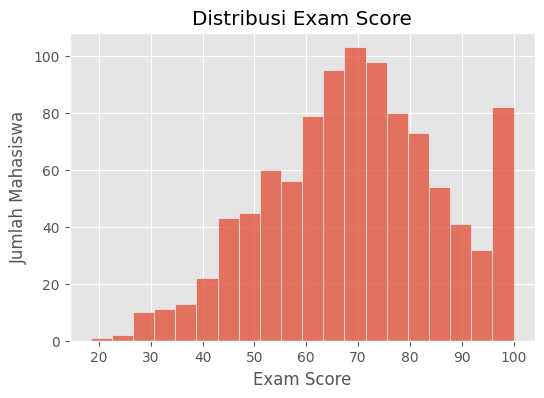

In [9]:
plt.figure(figsize=(6,4))
sns.histplot(df['exam_score'], bins=20)
plt.title("Distribusi Exam Score")
plt.xlabel("Exam Score")
plt.ylabel("Jumlah Mahasiswa")
plt.show()

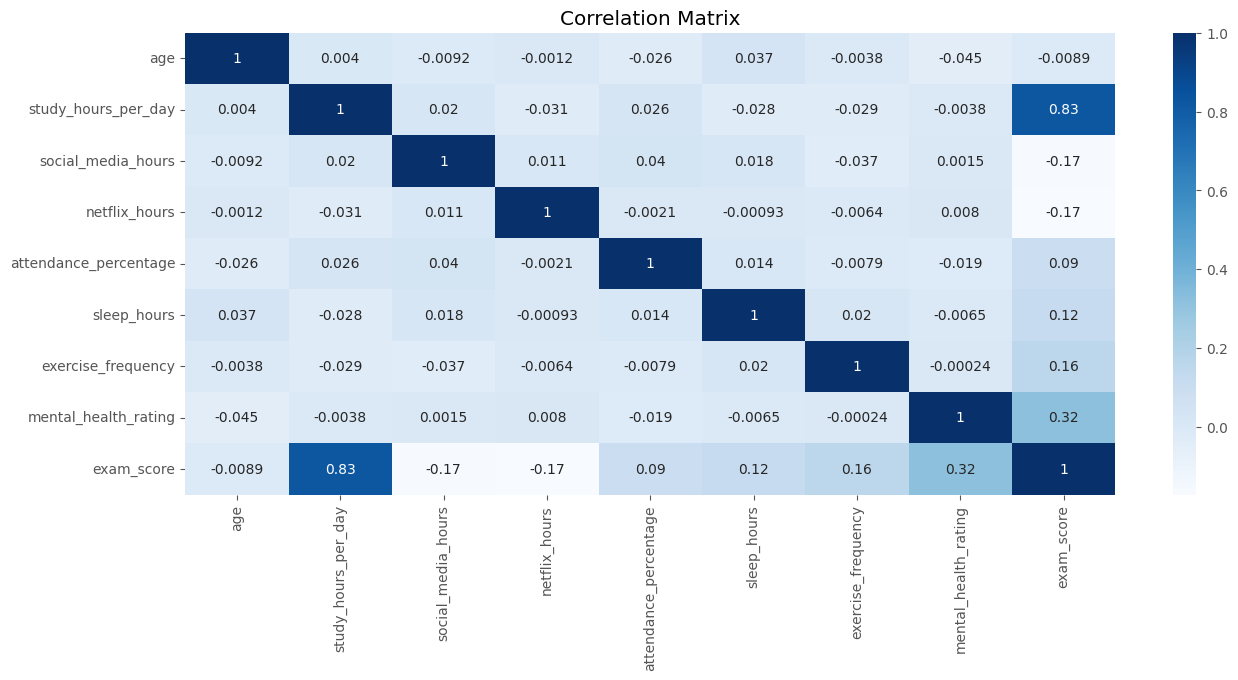

In [10]:
plt.figure(figsize=(15,6))

sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap="Blues")

plt.title("Correlation Matrix")
plt.show()

In [11]:
le = LabelEncoder()

categorical_cols = [
    "gender",
    "part_time_job",
    "diet_quality",
    "parental_education_level",
    "internet_quality",
    "extracurricular_participation"
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [12]:
# Membuat kategori performa akademik
def kategori(score):
    if score >= 70:
        return 'Tinggi'
    elif score >= 50:
        return 'Sedang'
    else:
        return 'Rendah'

df['performance'] = df['exam_score'].apply(kategori)

df[['exam_score', 'performance']].head()

,exam_score,performance
0,56.2,Sedang
1,100.0,Tinggi
2,34.3,Rendah
3,26.8,Rendah
4,66.4,Sedang


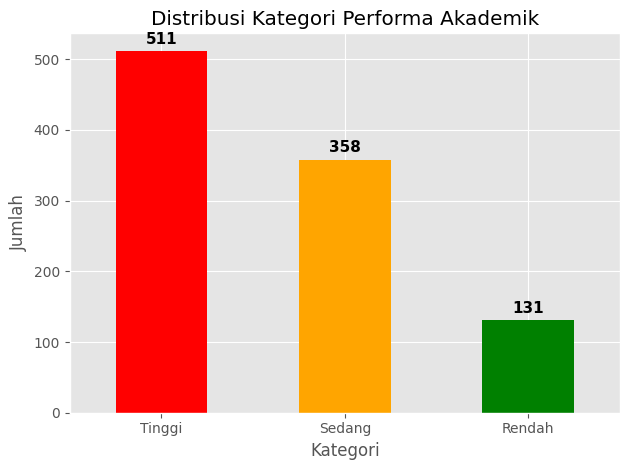

In [13]:
ax = df["performance"].value_counts().plot(
    kind="bar",
    color=["red", "orange", "green"]
)

plt.title("Distribusi Kategori Performa Akademik")
plt.xlabel("Kategori")
plt.ylabel("Jumlah")
plt.xticks(rotation=0)

ax.bar_label(ax.containers[0], fontsize=11, fontweight='bold', padding=3)

plt.tight_layout()
plt.show()

In [14]:
df[['student_id', 'exam_score']].head(10)

,student_id,exam_score
0,S1000,56.2
1,S1001,100.0
2,S1002,34.3
3,S1003,26.8
4,S1004,66.4
5,S1005,100.0
6,S1006,89.8
7,S1007,72.6
8,S1008,78.9
9,S1009,100.0


In [15]:
#Menentukan Fitur & Split Data

X = df.drop(columns=[
    "student_id",
    "exam_score",
    "performance"
])

y = df["performance"]

X_train, X_test, y_train, y_test = train_test_split(

    X,y,test_size=0.2, random_state=42, stratify=y

)

print("Jumlah Data Training :", len(X_train))
print("Jumlah Data Testing :", len(X_test))



Jumlah Data Training : 800
Jumlah Data Testing : 200


In [36]:
# Decision Tree

dt = DecisionTreeClassifier(

    random_state=42,

    max_depth=4

)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("=== Decision Tree ===")

print(classification_report(y_test, y_pred_dt, digits=3))

=== Decision Tree ===
              precision    recall  f1-score   support

      Rendah      0.500     0.769     0.606        26
      Sedang      0.623     0.597     0.610        72
      Tinggi      0.857     0.765     0.808       102

    accuracy                          0.705       200
   macro avg      0.660     0.710     0.675       200
weighted avg      0.726     0.705     0.711       200



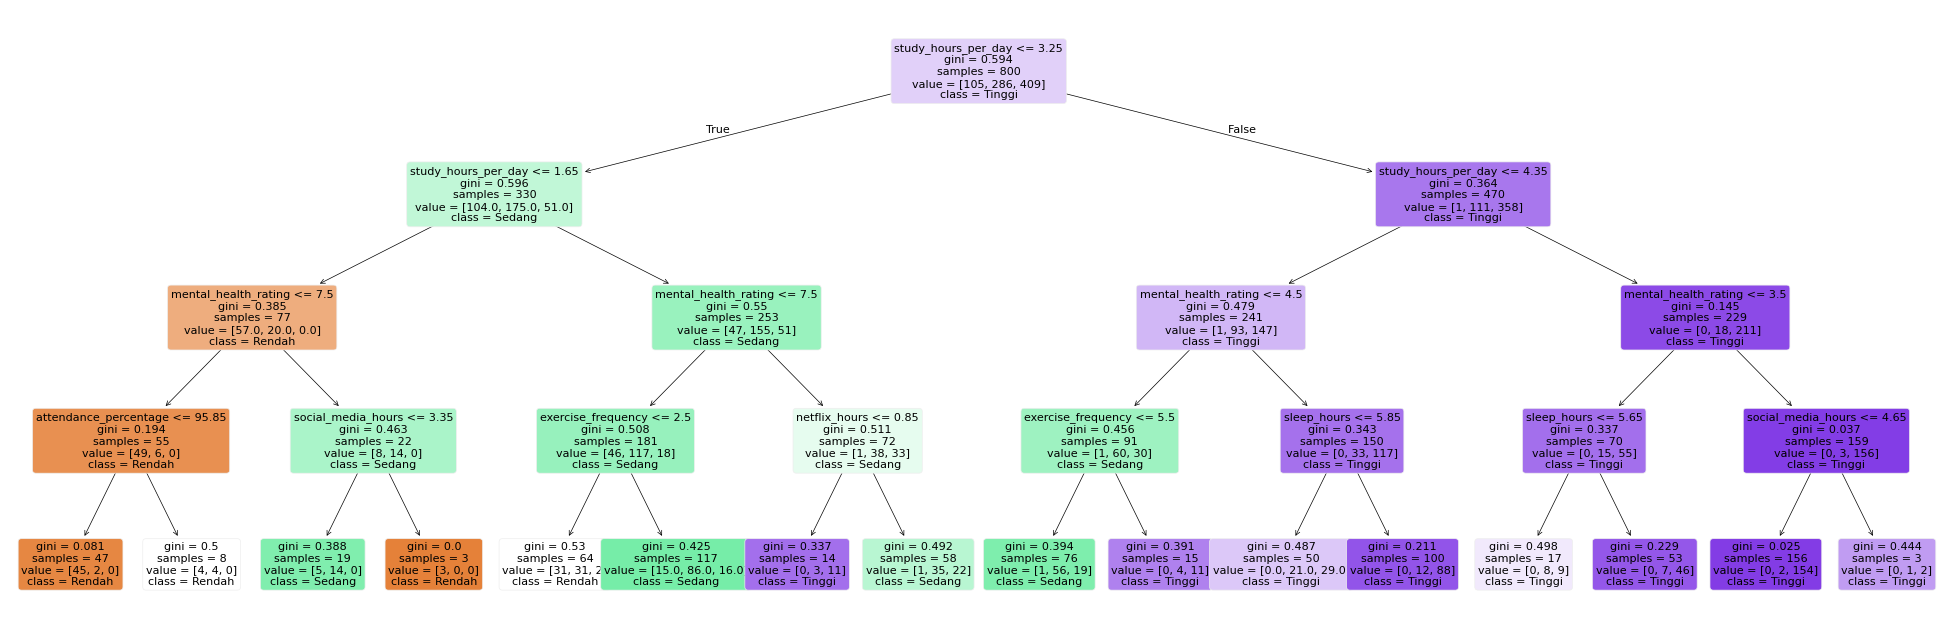

In [17]:
plt.figure(figsize=(25,8))

plot_tree(

    dt,

    feature_names=X.columns,

    class_names=["Rendah","Sedang","Tinggi"],

    filled=True,

    rounded=True,

    fontsize=8

)

plt.show()

In [18]:
# Contoh hasil prediksi Decision Tree

hasil_dt = X_test.reset_index(drop=True)

hasil_dt["Actual"] = y_test.reset_index(drop=True)
hasil_dt["Prediksi"] = y_pred_dt

hasil_dt[['study_hours_per_day',
          'sleep_hours',
          'attendance_percentage',
          'Actual',
          'Prediksi']].head(5)

,study_hours_per_day,sleep_hours,attendance_percentage,Actual,Prediksi
0,7.4,5.7,94.6,Tinggi,Tinggi
1,3.7,8.5,98.8,Sedang,Tinggi
2,3.6,6.0,75.1,Tinggi,Tinggi
3,3.3,6.8,67.1,Rendah,Sedang
4,5.0,6.8,78.9,Tinggi,Tinggi


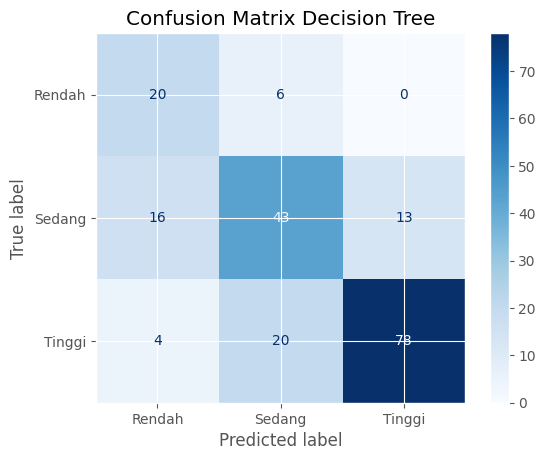

In [19]:
ConfusionMatrixDisplay.from_predictions(

    y_test,

    y_pred_dt,

    cmap="Blues"

)

plt.title("Confusion Matrix Decision Tree")

plt.show()

In [20]:
contoh_dt = df[[
    "student_id",
    "study_hours_per_day",
    "sleep_hours",
    "attendance_percentage",
    "performance"
]].head(5)

contoh_dt

,student_id,study_hours_per_day,sleep_hours,attendance_percentage,performance
0,S1000,0.0,8.0,85.0,Sedang
1,S1001,6.9,4.6,97.3,Tinggi
2,S1002,1.4,8.0,94.8,Rendah
3,S1003,1.0,9.2,71.0,Rendah
4,S1004,5.0,4.9,90.9,Sedang


=== Naive Bayes ===
              precision    recall  f1-score   support

      Rendah      0.765     0.500     0.605        26
      Sedang      0.675     0.778     0.723        72
      Tinggi      0.880     0.863     0.871       102

    accuracy                          0.785       200
   macro avg      0.773     0.714     0.733       200
weighted avg      0.791     0.785     0.783       200



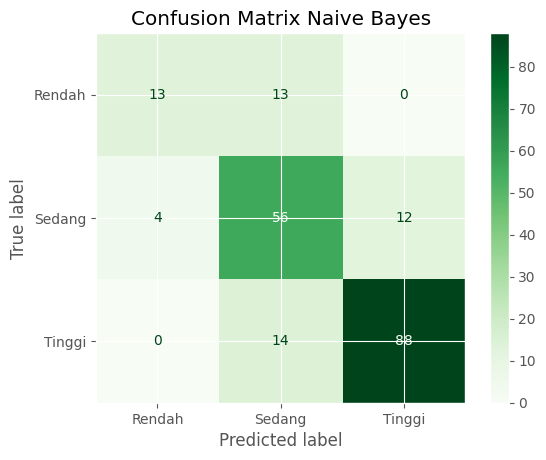

In [37]:
# Naive Bayes

nb = GaussianNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print("=== Naive Bayes ===")

print(classification_report(y_test, y_pred_nb, digits=3))

ConfusionMatrixDisplay.from_predictions(

    y_test,

    y_pred_nb,

    cmap="Greens"

)

plt.title("Confusion Matrix Naive Bayes")

plt.show()

In [22]:
hasil_dt = X_test.copy()
hasil_dt["Actual"] = y_test.values
hasil_dt["Prediksi"] = y_pred_dt

hasil_dt.head(5)

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,Actual,Prediksi
293,18,0,7.4,1.6,1.2,0,94.6,5.7,0,5,0,1,10,1,Tinggi,Tinggi
40,19,0,3.7,4.7,2.0,0,98.8,8.5,1,6,0,1,2,0,Sedang,Tinggi
805,20,0,3.6,2.2,2.2,0,75.1,6.0,0,3,0,0,10,1,Tinggi,Tinggi
927,20,0,3.3,4.0,1.9,0,67.1,6.8,1,0,0,1,2,0,Rendah,Sedang
589,21,1,5.0,2.3,0.2,0,78.9,6.8,2,6,0,1,1,0,Tinggi,Tinggi


In [23]:
# Menampilkan data yang diprediksi beserta probabilitasnya
prob = nb.predict_proba(X_test)
for i in range(5):
    print(f"\n===== Data ke-{i+1} =====")
    display(X_test.iloc[[i]])

    print(f"P(Rendah | data) = {prob[i][0]:.4f}")
    print(f"P(Sedang | data) = {prob[i][1]:.4f}")
    print(f"P(Tinggi | data) = {prob[i][2]:.4f}")

    print(f"Prediksi = {y_pred_nb[i]}")
    print("-"*60)


===== Data ke-1 =====


,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation
293,18,0,7.4,1.6,1.2,0,94.6,5.7,0,5,0,1,10,1


P(Rendah | data) = 0.0000
P(Sedang | data) = 0.0001
P(Tinggi | data) = 0.9999
Prediksi = Tinggi
------------------------------------------------------------

===== Data ke-2 =====


,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation
40,19,0,3.7,4.7,2.0,0,98.8,8.5,1,6,0,1,2,0


P(Rendah | data) = 0.0142
P(Sedang | data) = 0.3791
P(Tinggi | data) = 0.6067
Prediksi = Tinggi
------------------------------------------------------------

===== Data ke-3 =====


...

P(Rendah | data) = 0.0030
P(Sedang | data) = 0.2094
P(Tinggi | data) = 0.7875
Prediksi = Tinggi
------------------------------------------------------------

===== Data ke-4 =====


,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation
927,20,0,3.3,4.0,1.9,0,67.1,6.8,1,0,0,1,2,0


P(Rendah | data) = 0.1018
P(Sedang | data) = 0.7325
P(Tinggi | data) = 0.1657
Prediksi = Sedang
------------------------------------------------------------

===== Data ke-5 =====


,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation
589,21,1,5.0,2.3,0.2,0,78.9,6.8,2,6,0,1,1,0


P(Rendah | data) = 0.0001
P(Sedang | data) = 0.1322
P(Tinggi | data) = 0.8677
Prediksi = Tinggi
------------------------------------------------------------


In [24]:
from sklearn.metrics import accuracy_score

# ============================================================
# CEK OVERFITTING: Akurasi Training vs Testing
# ============================================================

# Decision Tree
train_acc_dt = accuracy_score(y_train, dt.predict(X_train))
test_acc_dt  = accuracy_score(y_test, dt.predict(X_test))

# Naive Bayes
train_acc_nb = accuracy_score(y_train, nb.predict(X_train))
test_acc_nb  = accuracy_score(y_test, nb.predict(X_test))

print("=== Decision Tree ===")
print(f"Akurasi Training : {train_acc_dt:.4f} ({train_acc_dt*100:.2f}%)")
print(f"Akurasi Testing  : {test_acc_dt:.4f} ({test_acc_dt*100:.2f}%)")
print(f"Selisih (gap)    : {(train_acc_dt-test_acc_dt)*100:.2f}%")

print("\n=== Naive Bayes ===")
print(f"Akurasi Training : {train_acc_nb:.4f} ({train_acc_nb*100:.2f}%)")
print(f"Akurasi Testing  : {test_acc_nb:.4f} ({test_acc_nb*100:.2f}%)")
print(f"Selisih (gap)    : {(train_acc_nb-test_acc_nb)*100:.2f}%")

=== Decision Tree ===
Akurasi Training : 0.7800 (78.00%)
Akurasi Testing  : 0.7050 (70.50%)
Selisih (gap)    : 7.50%

=== Naive Bayes ===
Akurasi Training : 0.8225 (82.25%)
Akurasi Testing  : 0.7850 (78.50%)
Selisih (gap)    : 3.75%


In [25]:
# Perbandingan Hasil

hasil = pd.DataFrame({
    'Algoritma': ['Decision Tree', 'Naive Bayes'],

    'Accuracy': [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_nb)
    ],

    'Precision': [
        precision_score(y_test, y_pred_dt, average='weighted'),
        precision_score(y_test, y_pred_nb, average='weighted')
    ],

    'Recall': [
        recall_score(y_test, y_pred_dt, average='weighted'),
        recall_score(y_test, y_pred_nb, average='weighted')
    ],

    'F1-Score': [
        f1_score(y_test, y_pred_dt, average='weighted'),
        f1_score(y_test, y_pred_nb, average='weighted')
    ]
})

hasil

,Algoritma,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.705,0.726491,0.705,0.71059
1,Naive Bayes,0.785,0.791103,0.785,0.78309


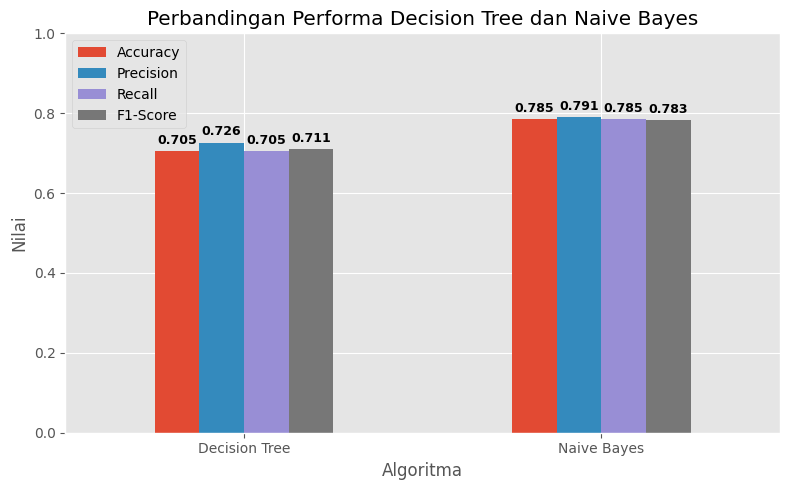

In [26]:
hasil = pd.DataFrame({
    'Algoritma': ['Decision Tree', 'Naive Bayes'],
    'Accuracy' : [accuracy_score(y_test, y_pred_dt), accuracy_score(y_test, y_pred_nb)],
    'Precision': [precision_score(y_test, y_pred_dt, average='weighted'), precision_score(y_test, y_pred_nb, average='weighted')],
    'Recall'   : [recall_score(y_test, y_pred_dt, average='weighted'),    recall_score(y_test, y_pred_nb, average='weighted')],
    'F1-Score' : [f1_score(y_test, y_pred_dt, average='weighted'),        f1_score(y_test, y_pred_nb, average='weighted')]
})

ax = hasil.set_index("Algoritma").plot(kind="bar", figsize=(8, 5))

plt.ylabel("Nilai")
plt.title("Perbandingan Performa Decision Tree dan Naive Bayes")
plt.xticks(rotation=0)
plt.ylim(0, 1)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

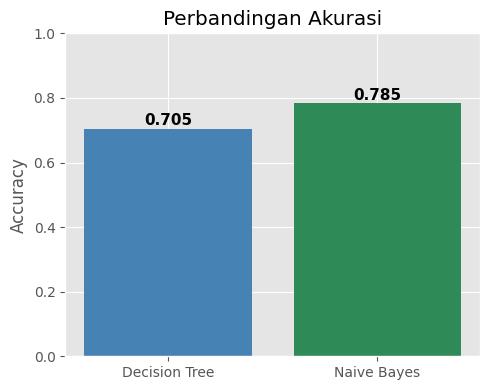

In [27]:
plt.figure(figsize=(5, 4))

ax = plt.bar(hasil["Algoritma"], hasil["Accuracy"], color=["steelblue", "seagreen"])

plt.ylim(0, 1)
plt.title("Perbandingan Akurasi")
plt.ylabel("Accuracy")

for bar in ax:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f'{bar.get_height():.3f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## ROC Curve dan AUC Score

In [28]:
# ============================================================
# ROC CURVE & AUC SCORE (One-vs-Rest, 3 Kelas)
# ============================================================
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score, auc

# Label sebenarnya (y_true) dan probabilitas hasil prediksi model
classes = dt.classes_          # ['Rendah', 'Sedang', 'Tinggi']
n_classes = len(classes)

y_test_bin = label_binarize(y_test, classes=classes)

# Probabilitas hasil prediksi model
y_score_dt = dt.predict_proba(X_test)
y_score_nb = nb.predict_proba(X_test)


In [29]:
# ============================================================
# ROC & AUC - DECISION TREE
# ============================================================
fpr_dt, tpr_dt, roc_auc_dt = {}, {}, {}

for i, kelas in enumerate(classes):
    fpr_dt[i], tpr_dt[i], _ = roc_curve(y_test_bin[:, i], y_score_dt[:, i])
    roc_auc_dt[i] = auc(fpr_dt[i], tpr_dt[i])
    print(f"Nilai AUC kelas {kelas} (Decision Tree) =", roc_auc_dt[i])

auc_macro_dt = roc_auc_score(y_test_bin, y_score_dt, average='macro', multi_class='ovr')
print("\nNilai AUC rata-rata (macro) Decision Tree =", auc_macro_dt)


Nilai AUC kelas Rendah (Decision Tree) = 0.9126878868258178
Nilai AUC kelas Sedang (Decision Tree) = 0.7698025173611112
Nilai AUC kelas Tinggi (Decision Tree) = 0.884203681472589

Nilai AUC rata-rata (macro) Decision Tree = 0.8555646952198392


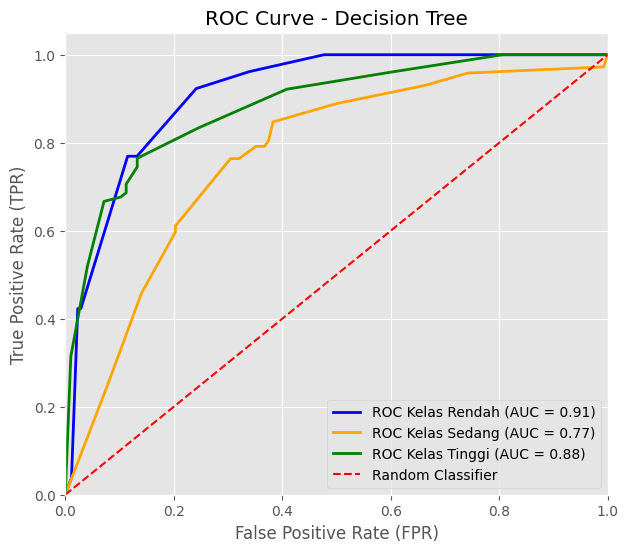

In [30]:
# Menampilkan kurva ROC - Decision Tree
plt.figure(figsize=(7,6))

warna = ['blue', 'orange', 'green']

for i, kelas in enumerate(classes):
    plt.plot(fpr_dt[i], tpr_dt[i],
             color=warna[i],
             linewidth=2,
             label=f'ROC Kelas {kelas} (AUC = %0.2f)' % roc_auc_dt[i])

# Garis 45 derajat (Random Classifier)
plt.plot([0,1],[0,1],
         linestyle='--',
         color='red',
         label='Random Classifier')

plt.xlim([0,1])
plt.ylim([0,1.05])
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve - Decision Tree")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [31]:
# ============================================================
# ROC & AUC - NAIVE BAYES
# ============================================================
fpr_nb, tpr_nb, roc_auc_nb = {}, {}, {}

for i, kelas in enumerate(classes):
    fpr_nb[i], tpr_nb[i], _ = roc_curve(y_test_bin[:, i], y_score_nb[:, i])
    roc_auc_nb[i] = auc(fpr_nb[i], tpr_nb[i])
    print(f"Nilai AUC kelas {kelas} (Naive Bayes) =", roc_auc_nb[i])

auc_macro_nb = roc_auc_score(y_test_bin, y_score_nb, average='macro', multi_class='ovr')
print("\nNilai AUC rata-rata (macro) Naive Bayes =", auc_macro_nb)


Nilai AUC kelas Rendah (Naive Bayes) = 0.9529177718832891
Nilai AUC kelas Sedang (Naive Bayes) = 0.8543836805555556
Nilai AUC kelas Tinggi (Naive Bayes) = 0.9489795918367347

Nilai AUC rata-rata (macro) Naive Bayes = 0.9187603480918597


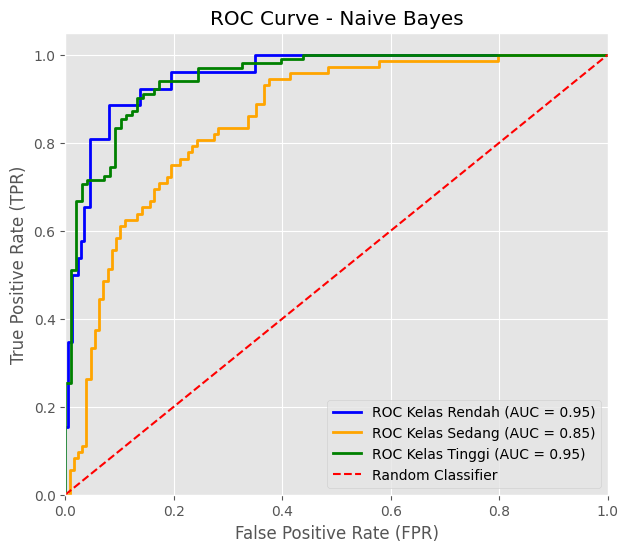

In [32]:
# Menampilkan kurva ROC - Naive Bayes
plt.figure(figsize=(7,6))

for i, kelas in enumerate(classes):
    plt.plot(fpr_nb[i], tpr_nb[i],
             color=warna[i],
             linewidth=2,
             label=f'ROC Kelas {kelas} (AUC = %0.2f)' % roc_auc_nb[i])

# Garis 45 derajat (Random Classifier)
plt.plot([0,1],[0,1],
         linestyle='--',
         color='red',
         label='Random Classifier')

plt.xlim([0,1])
plt.ylim([0,1.05])
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve - Naive Bayes")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [33]:
# ============================================================
# Perbandingan AUC (macro) Decision Tree vs Naive Bayes
# ============================================================
perbandingan_auc = pd.DataFrame({
    'Algoritma': ['Decision Tree', 'Naive Bayes'],
    'AUC (macro)': [auc_macro_dt, auc_macro_nb]
})

perbandingan_auc


,Algoritma,AUC (macro)
0,Decision Tree,0.855565
1,Naive Bayes,0.918760
